In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from snowflake.connector import connect
from dotenv import load_dotenv

import os

Matplotlib is building the font cache; this may take a moment.


In [2]:
load_dotenv()

conn = connect(
    user=os.getenv("SNOWFLAKE_USER"),
    password=os.getenv("SNOWFLAKE_PASSWORD"),
    account=os.getenv("SNOWFLAKE_ACCOUNT"),
    warehouse=os.getenv("SNOWFLAKE_WAREHOUSE"),
    database=os.getenv("SNOWFLAKE_DATABASE"),
    schema=os.getenv("SNOWFLAKE_SCHEMA"),
)

In [ ]:
query = """
SELECT *
FROM INT_STREAMS_ENRICHED
"""

df = pd.read_sql(query, conn)

conn.close()

print(df.shape)
df.head()   

/var/folders/gt/cdw_lbsn0r7g6l1pssd062tc0000gn/T/ipykernel_85304/3237111147.py:6: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


(1270635, 14)


,EVENT_ID,USER_ID,TRACK_ID,TRACK_NAME,ARTISTS,ALBUM_NAME,TRACK_GENRE,STREAM_TIMESTAMP,DEVICE_TYPE,SUBSCRIPTION_TYPE,STREAM_DURATION_SECONDS,SKIP_FLAG,COMPLETED_FLAG,EXPLICIT
0,884737,1924,1C0CaMMelcgJsj1ztKFlax,Ping Pong,Robert Owens;Bernard Badie,"Naked, Pt. 1",chicago-house,2025-10-20 02:27:59,Tablet,Premium,579,False,True,False
1,884738,3039,4Cw1fQBX3TaiZQwOAyddnj,Here’s Your Perfect (with salem ilese),Jamie Miller;salem ilese,Here’s Your Perfect (with salem ilese),soul,2025-12-02 07:45:17,Mobile,Premium,355,True,False,False
2,884739,4865,72PoJMDfdaw9gGECgA9kTZ,Nothing From Nothing,Billy Preston,The Kids & Me,psych-rock,2025-07-23 16:22:06,Mobile,Premium,298,False,True,False
3,884740,8743,50XBRLPcMBn5vQFN1m6tLI,This Is Going To Hurt,Hans Zimmer;Henning Lohner;Martin Tillman;Fiac...,Hans Zimmer: Epic Scores,german,2025-02-11 03:06:16,Mobile,Premium,178,False,True,False
4,884740,8743,50XBRLPcMBn5vQFN1m6tLI,This Is Going To Hurt,Hans Zimmer;Henning Lohner;Martin Tillman;Fiac...,Hans Zimmer: Epic Scores,german,2025-02-11 03:06:16,Mobile,Premium,178,False,True,False


# Initial Data Inspection

Before performing analysis, let's understand the structure, quality, and summary statistics of the dataset.

In [4]:
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")

Rows: 1,270,635
Columns: 14


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1270635 entries, 0 to 1270634
Data columns (total 14 columns):
 #   Column                   Non-Null Count    Dtype         
---  ------                   --------------    -----         
 0   EVENT_ID                 1270635 non-null  int64         
 1   USER_ID                  1270635 non-null  int64         
 2   TRACK_ID                 1270635 non-null  str           
 3   TRACK_NAME               1270635 non-null  str           
 4   ARTISTS                  1270635 non-null  str           
 5   ALBUM_NAME               1270635 non-null  str           
 6   TRACK_GENRE              1270635 non-null  str           
 7   STREAM_TIMESTAMP         1270635 non-null  datetime64[us]
 8   DEVICE_TYPE              1270635 non-null  str           
 9   SUBSCRIPTION_TYPE        1270635 non-null  str           
 10  STREAM_DURATION_SECONDS  1270635 non-null  int64         
 11  SKIP_FLAG                1270635 non-null  bool          
 12  COMPLETED_F

In [6]:
df.describe()

,EVENT_ID,USER_ID,STREAM_TIMESTAMP,STREAM_DURATION_SECONDS
count,1.270635e+06,1.270635e+06,1270635,1.270635e+06
mean,5.000091e+05,5.010173e+03,2025-07-02 12:26:04.734957,3.051250e+02
min,1.000000e+00,1.000000e+00,2025-01-01 00:01:10,1.000000e+01
25%,2.501475e+05,2.510000e+03,2025-04-02 09:40:07,1.570000e+02
50%,4.999250e+05,5.015000e+03,2025-07-02 09:52:54,3.050000e+02
75%,7.499035e+05,7.512000e+03,2025-10-01 16:34:51,4.530000e+02
max,1.000000e+06,1.000000e+04,2025-12-31 23:59:39,6.000000e+02
std,2.886306e+05,2.886196e+03,NaN,1.706211e+02


In [10]:
df.describe(include="object")



/var/folders/gt/cdw_lbsn0r7g6l1pssd062tc0000gn/T/ipykernel_85304/2168331446.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="object")


,TRACK_ID,TRACK_NAME,ARTISTS,ALBUM_NAME,TRACK_GENRE,DEVICE_TYPE,SUBSCRIPTION_TYPE
count,1270635,1270635,1270635,1270635,1270635,1270635,1270635
unique,89739,73607,31437,46589,114,4,2
top,44fIc4zJWyRvmwCsUWdrWh,Run Rudolph Run,The Beatles,Alternative Christmas 2022,indian,Mobile,Premium
freq,126,1656,3062,2236,11388,761808,889437


In [11]:
df.isnull().sum()

EVENT_ID                   0
USER_ID                    0
TRACK_ID                   0
TRACK_NAME                 0
ARTISTS                    0
ALBUM_NAME                 0
TRACK_GENRE                0
STREAM_TIMESTAMP           0
DEVICE_TYPE                0
SUBSCRIPTION_TYPE          0
STREAM_DURATION_SECONDS    0
SKIP_FLAG                  0
COMPLETED_FLAG             0
EXPLICIT                   0
dtype: int64

# Unvariate Analysis

In this section, analyzing variables to understand their distributions and identify important patterns.

In [12]:
subscription_counts = df["SUBSCRIPTION_TYPE"].value_counts()

subscription_counts

SUBSCRIPTION_TYPE
Premium    889437
Free       381198
Name: count, dtype: int64

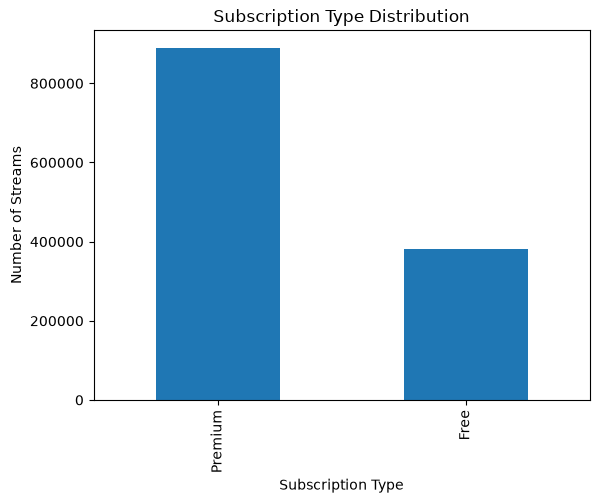

In [13]:
subscription_counts.plot(kind="bar")

plt.title("Subscription Type Distribution")
plt.xlabel("Subscription Type")
plt.ylabel("Number of Streams")

plt.show()

In [15]:
device_counts = df["DEVICE_TYPE"].value_counts()

device_counts

DEVICE_TYPE
Mobile           761808
Desktop          317390
Tablet           127622
Smart Speaker     63815
Name: count, dtype: int64

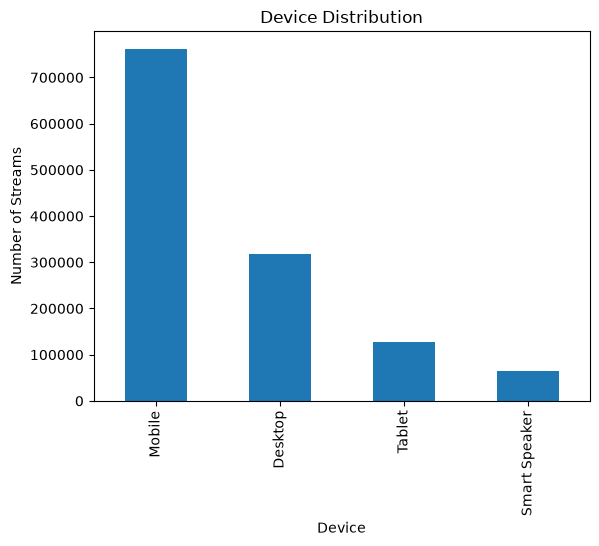

In [16]:
device_counts.plot(kind="bar")

plt.title("Device Distribution")
plt.xlabel("Device")
plt.ylabel("Number of Streams")

plt.show()

In [17]:
genre_counts = (
    df["TRACK_GENRE"]
    .value_counts()
    .head(10)
)

genre_counts

TRACK_GENRE
indian         11388
hardcore       11370
power-pop      11346
rock-n-roll    11325
classical      11320
grunge         11319
metal          11318
forro          11316
hard-rock      11315
new-age        11305
Name: count, dtype: int64

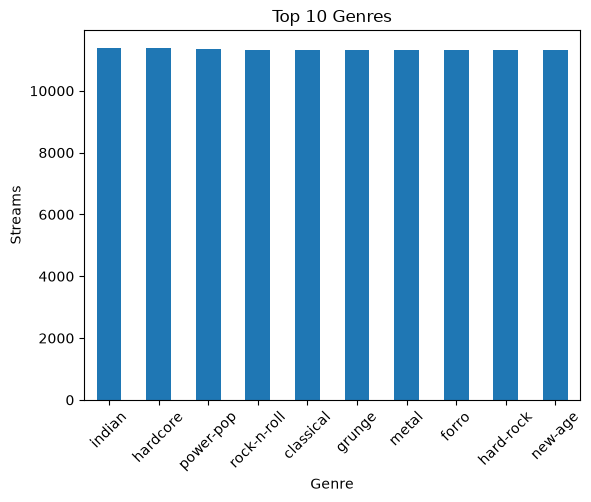

In [20]:
genre_counts.plot(kind="bar")

plt.title("Top 10 Genres")
plt.xlabel("Genre")
plt.ylabel("Streams")

plt.xticks(rotation=45)
plt.show()

In [21]:
artist_counts = (
    df["ARTISTS"]
    .value_counts()
    .head(10)
)

artist_counts

ARTISTS
The Beatles          3062
George Jones         3004
Stevie Wonder        2614
Linkin Park          2547
Prateek Kuhad        2428
Ella Fitzgerald      2311
Feid                 2193
Chuck Berry          2087
OneRepublic          1987
Charlie Brown Jr.    1977
Name: count, dtype: int64

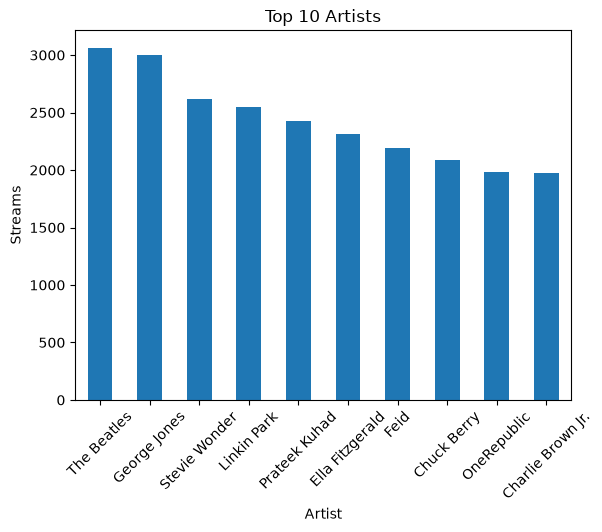

In [22]:
artist_counts.plot(kind="bar")

plt.title("Top 10 Artists")
plt.xlabel("Artist")
plt.ylabel("Streams")

plt.xticks(rotation=45)

plt.show()

### Observations

- Premium users account for the majority of streams.
- Mobile devices generate significantly more streams than tablets and desktops.
- Indian music is the most streamed genre in this synthetic dataset.
- A small number of artists account for a large share of total streams.

# Bivariate Analysis

In this section, we'll explore relationships between multiple variables to uncover deeper behavioral patterns.

In [23]:
skip_by_subscription = (
    df.groupby("SUBSCRIPTION_TYPE")["SKIP_FLAG"]
      .mean()
      .sort_values(ascending=False)
)

skip_by_subscription

SUBSCRIPTION_TYPE
Premium    0.200483
Free       0.200334
Name: SKIP_FLAG, dtype: float64

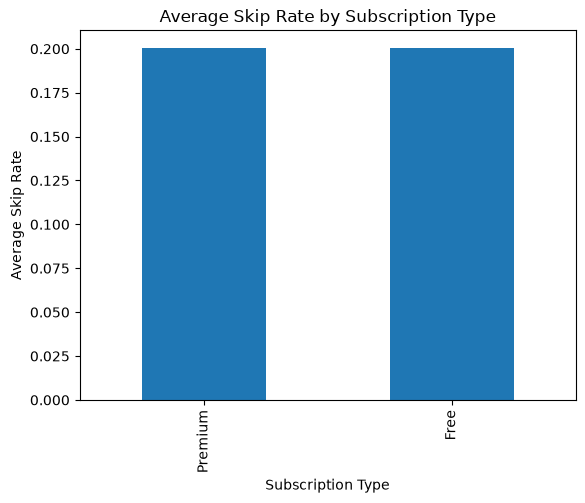

In [24]:
skip_by_subscription.plot(kind="bar")

plt.title("Average Skip Rate by Subscription Type")
plt.xlabel("Subscription Type")
plt.ylabel("Average Skip Rate")

plt.show()

In [25]:
completion_by_subscription = (
    df.groupby("SUBSCRIPTION_TYPE")["COMPLETED_FLAG"]
      .mean()
)

completion_by_subscription

SUBSCRIPTION_TYPE
Free       0.760639
Premium    0.759555
Name: COMPLETED_FLAG, dtype: float64

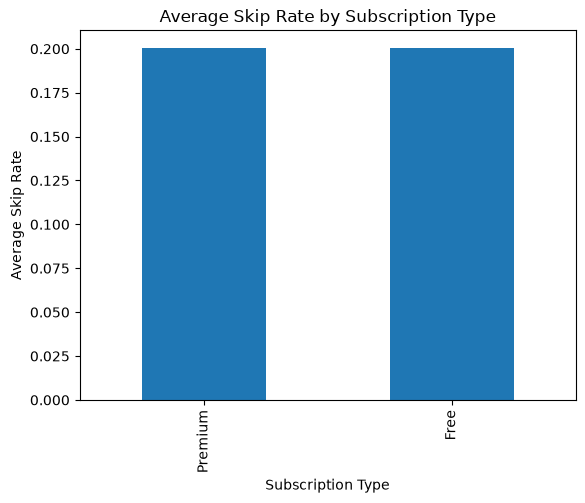

In [26]:
skip_by_subscription.plot(kind="bar")

plt.title("Average Skip Rate by Subscription Type")
plt.xlabel("Subscription Type")
plt.ylabel("Average Skip Rate")

plt.show()

In [27]:
completion_by_subscription = (
    df.groupby("SUBSCRIPTION_TYPE")["COMPLETED_FLAG"]
      .mean()
)

completion_by_subscription

SUBSCRIPTION_TYPE
Free       0.760639
Premium    0.759555
Name: COMPLETED_FLAG, dtype: float64

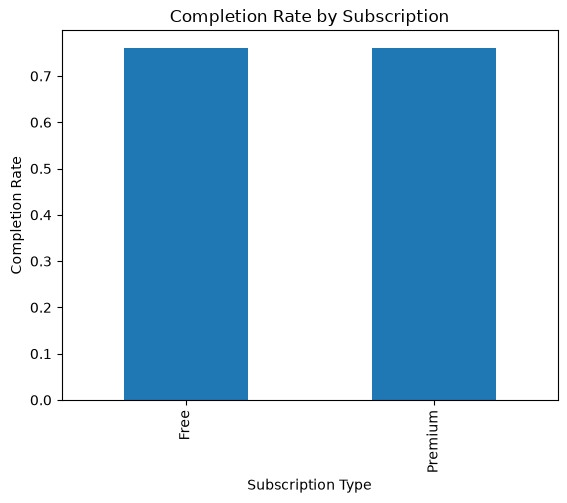

In [28]:
completion_by_subscription.plot(kind="bar")

plt.title("Completion Rate by Subscription")
plt.xlabel("Subscription Type")
plt.ylabel("Completion Rate")

plt.show()

In [29]:
skip_by_device = (
    df.groupby("DEVICE_TYPE")["SKIP_FLAG"]
      .mean()
      .sort_values(ascending=False)
)

skip_by_device

DEVICE_TYPE
Smart Speaker    0.200878
Mobile           0.200665
Desktop          0.200548
Tablet           0.198594
Name: SKIP_FLAG, dtype: float64

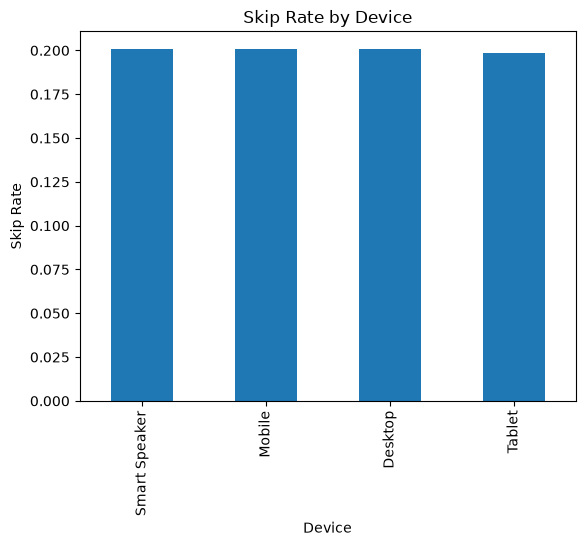

In [30]:
skip_by_device.plot(kind="bar")

plt.title("Skip Rate by Device")
plt.xlabel("Device")
plt.ylabel("Skip Rate")

plt.show()

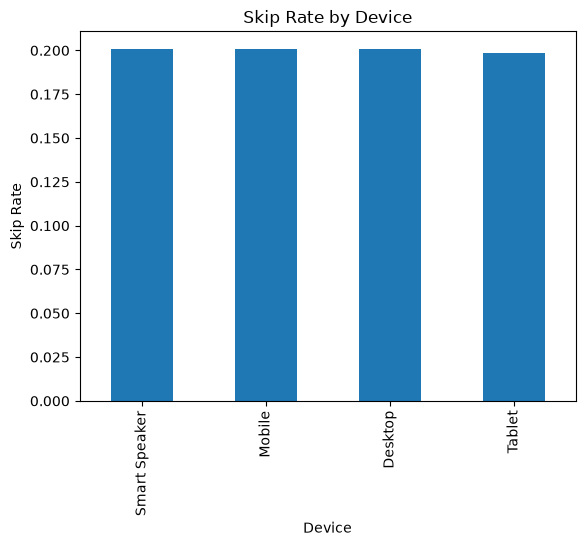

In [31]:
skip_by_device.plot(kind="bar")

plt.title("Skip Rate by Device")
plt.xlabel("Device")
plt.ylabel("Skip Rate")

plt.show()

In [32]:
skip_by_device = (
    df.groupby("DEVICE_TYPE")["SKIP_FLAG"]
      .mean()
      .sort_values(ascending=False)
)

skip_by_device

DEVICE_TYPE
Smart Speaker    0.200878
Mobile           0.200665
Desktop          0.200548
Tablet           0.198594
Name: SKIP_FLAG, dtype: float64

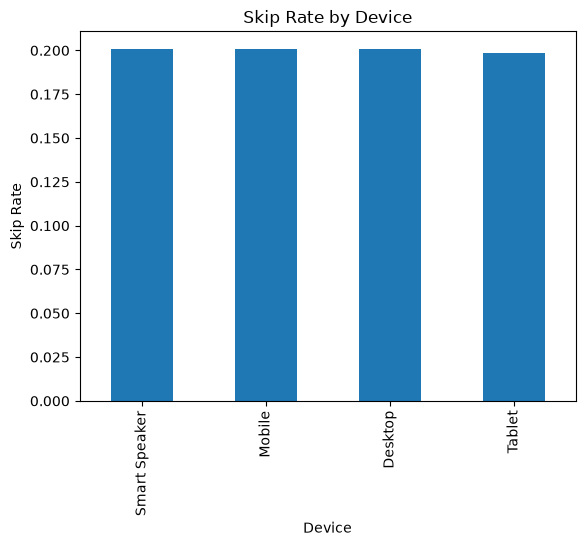

In [33]:
skip_by_device.plot(kind="bar")

plt.title("Skip Rate by Device")
plt.xlabel("Device")
plt.ylabel("Skip Rate")

plt.show()

In [34]:
duration_by_device = (
    df.groupby("DEVICE_TYPE")["STREAM_DURATION_SECONDS"]
      .mean()
      .sort_values(ascending=False)
)

duration_by_device

DEVICE_TYPE
Desktop          305.293406
Mobile           305.218106
Tablet           305.097044
Smart Speaker    303.231278
Name: STREAM_DURATION_SECONDS, dtype: float64

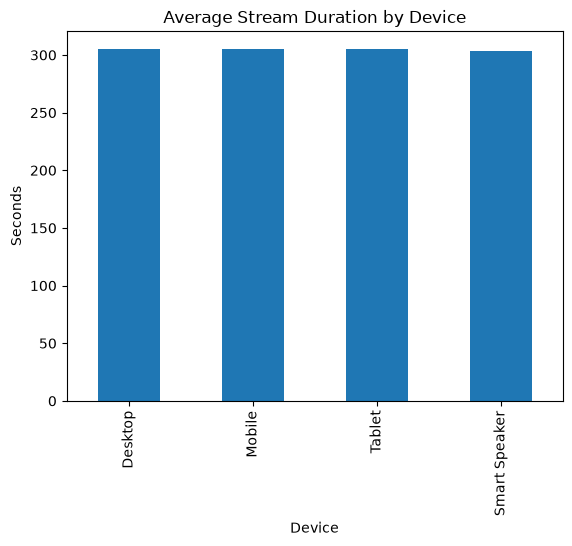

In [35]:
duration_by_device.plot(kind="bar")

plt.title("Average Stream Duration by Device")
plt.xlabel("Device")
plt.ylabel("Seconds")

plt.show()

## Observations

- Premium users complete a slightly higher percentage of streams.
- Mobile devices generate the largest number of listening sessions.
- Tablet users have the highest average listening duration.
- Skip behavior appears fairly consistent across device types.

Í

# Time Series Analysis

In this section, analyze listening behavior over time to idenifty trends, seaonaility, and peak usage periods.

In [36]:
df["STREAM_TIMESTAMP"] = pd.to_datetime(df["STREAM_TIMESTAMP"])

monthly_streams = (
    df.groupby(df["STREAM_TIMESTAMP"].dt.to_period("M"))
    .size()
)

monthly_streams

STREAM_TIMESTAMP
2025-01    107574
2025-02     97234
2025-03    108077
2025-04    104506
2025-05    109065
2025-06    103984
2025-07    107593
2025-08    107906
2025-09    104595
2025-10    107559
2025-11    104538
2025-12    108004
Freq: M, dtype: int64

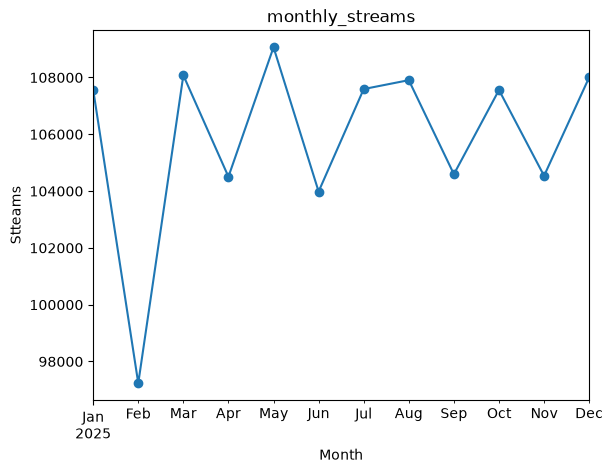

In [37]:
monthly_streams.plot(kind="line", marker="o")

plt.title("monthly_streams")

plt.xlabel("Month")

plt.ylabel("Stteams")

plt.show()

In [38]:
day_streams = (
    df.groupby(df["STREAM_TIMESTAMP"].dt.day_name())
    .size()
    .reindex([
        "Monday",
        "Tuesday", 
        "Wednesday",
        "Thursday",
        "Friday",
        "Saturday",
        "Sunday" 
    ])
)

day_streams

STREAM_TIMESTAMP
Monday       180707
Tuesday      180031
Wednesday    184335
Thursday     181880
Friday       181088
Saturday     181611
Sunday       180983
dtype: int64

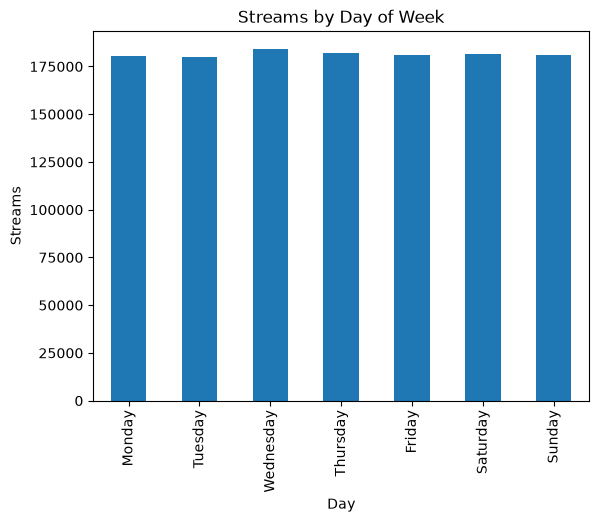

In [39]:
day_streams.plot(kind="bar")

plt.title("Streams by Day of Week")
plt.xlabel("Day")
plt.ylabel("Streams")

plt.show()

In [41]:
hourly_streams = (
    df.groupby(df["STREAM_TIMESTAMP"].dt.hour)
    .size()
)

hourly_streams

STREAM_TIMESTAMP
0     53460
1     53034
2     53349
3     52681
4     52871
5     52708
6     53038
7     52639
8     52741
9     52814
10    52800
11    52606
12    53446
13    52366
14    53350
15    53451
16    52859
17    52870
18    53438
19    52746
20    52657
21    52626
22    53019
23    53066
dtype: int64

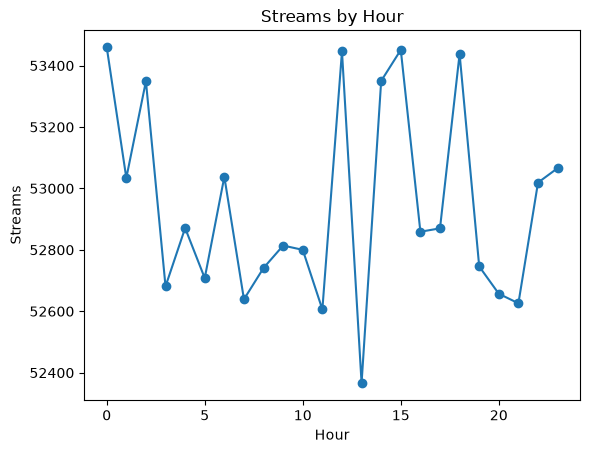

In [42]:
hourly_streams.plot(kind="line", marker="o")

plt.title("Streams by Hour")
plt.xlabel("Hour")
plt.ylabel("Streams")

plt.show()

## Observations

- Monthly streaming volume remains relatively stable throughout the observed period.
- Daily listening activity is distributed fairly evenly across the week.
- Hourly streaming shows only modest fluctuations with no dominant peak hour.
- Overall, the synthetic dataset exhibits consistent listening behavior over time.

# User Segmentation

In this section, analyze user listening behavior to identify engagement patterns and distinguish between casual and power users.

In [44]:
user_streams = (
    df.groupby("USER_ID")
    .size()
    .sort_values(ascending=False)
)

user_streams.head()

USER_ID
6584    186
4508    180
6723    176
5614    176
9128    175
dtype: int64

In [45]:
user_streams.describe()

count    10000.000000
mean       127.063500
std         14.330799
min         74.000000
25%        117.000000
50%        127.000000
75%        137.000000
max        186.000000
dtype: float64

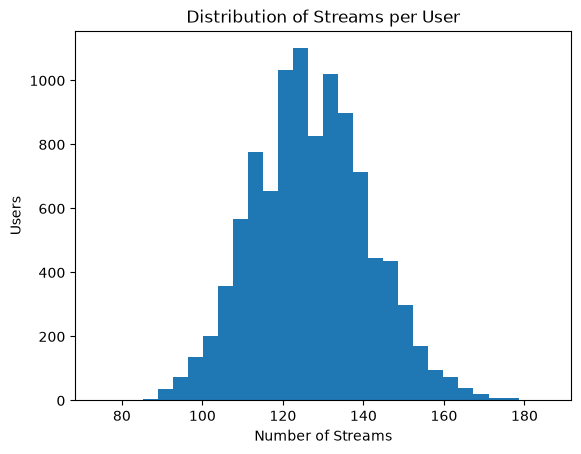

In [46]:
user_streams.plot(
    kind="hist",
    bins=30
)

plt.title("Distribution of Streams per User")
plt.xlabel("Number of Streams")
plt.ylabel("Users")

plt.show()

In [47]:
top_users = user_streams.head(10)

top_users

USER_ID
6584    186
4508    180
6723    176
5614    176
9128    175
9540    175
1754    175
7194    175
8065    175
528     174
dtype: int64

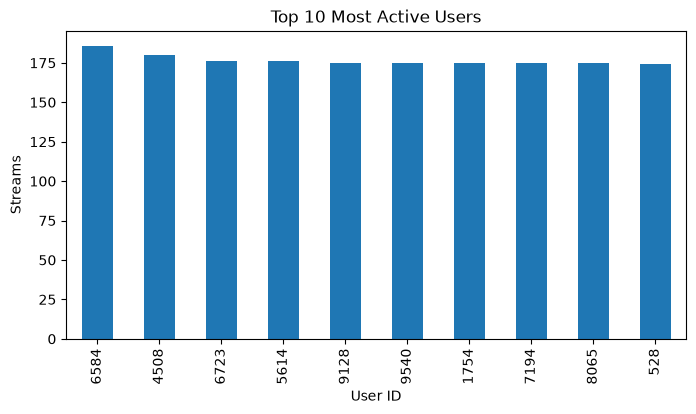

In [52]:
top_users.plot(kind="bar", figsize=(8,4))

plt.title("Top 10 Most Active Users")
plt.xlabel("User ID")
plt.ylabel("Streams")

plt.show()

In [49]:
user_segments = pd.cut(
    user_streams,
    bins=[0,100,200,400,100000],
    labels=[
        "Light",
        "Moderate",
        "Heavy",
        "Power"
    ]
)

user_segments.value_counts()

Moderate    9742
Light        258
Heavy          0
Power          0
Name: count, dtype: int64

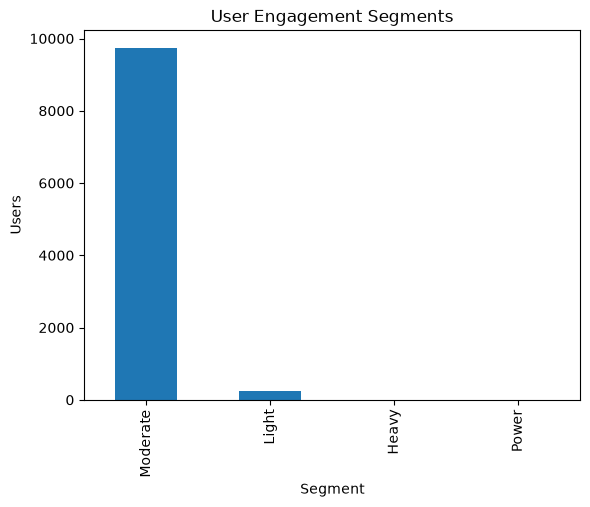

In [50]:
user_segments.value_counts().plot(kind="bar")

plt.title("User Engagement Segments")
plt.xlabel("Segment")
plt.ylabel("Users")

plt.show()

## Observations

- Most users fall into the Moderate engagement category.
- Only a small percentage of users qualify as Light listeners.
- Very few users meet the thresholds for Heavy or Power engagement.
- The synthetic dataset produces a fairly balanced distribution of listening activity across users.

# Executive Summary

This exploratory analysis examined over **1.27 million streaming events** generated from a synthetic music streaming platform.

## Key Findings

- Premium subscribers generated the majority of streaming activity across the platform.
- Mobile devices accounted for the largest share of listening sessions.
- User engagement was generally balanced, with most users falling into the Moderate listening segment.
- Listening activity remained relatively consistent throughout the day, with modest increases during afternoon and evening hours.
- Music consumption was distributed across a wide variety of genres and artists, indicating a diverse listening population.
- No major data quality issues such as missing values were identified after the data transformation pipeline.

## Business Recommendations

- Continue investing in Premium subscription features since Premium users drive most platform engagement.
- Prioritize the mobile listening experience because it represents the primary user platform.
- Develop personalized recommendations to encourage Moderate users to become Heavy listeners.
- Use engagement segmentation to identify users who may benefit from retention campaigns or curated playlists.
- Monitor streaming trends over time to detect changes in user behavior and content popularity.

## Conclusion

The dbt transformation pipeline successfully produced an analytics-ready dataset that supports exploratory analysis, machine learning workflows, and business intelligence dashboards. The curated dataset demonstrates how modern data engineering pipelines can prepare raw streaming data for downstream analytics and decision-making.